# Data preparation and feature engineering

Builds the modelling table for delivery-time prediction: target definition,
feature construction, and the checks that decide what goes into the model.

96,470 delivered orders, September 2016 to August 2018.
Output: `data/clean/clean.parquet`, consumed by notebook 03.

## 1. Data loading & filtering

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [3]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [4]:
delivered = orders[orders['order_status'] == "delivered"].copy()
delivered = delivered.dropna(subset = ["order_delivered_customer_date"])

In [5]:
print(orders.shape)
print(delivered.shape)

(99441, 8)
(96470, 8)


## 2. Target: delivery_days

In [6]:
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])
delivered['order_delivered_customer_date'] = pd.to_datetime(delivered['order_delivered_customer_date'])

delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.total_seconds() / 86400

In [7]:
delivered['delivery_days'].describe()

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64

In [8]:
print("Delivered within 24h:", (delivered['delivery_days'] < 1).sum())
delivered[delivered['delivery_days'] < 1][
    ['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date', 'delivery_days']
]

Delivered within 24h: 13


,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days
395,38c1e3d4ed6a13cd0cf612d4c09766e9,2018-02-02 15:26:38,2018-02-03 15:05:56,0.985625
735,d3ca7b82c922817b06e5ca21165c5ea2,2017-11-16 13:54:08,2017-11-17 13:49:40,0.996898
31522,1d893dd7ca5f77ebf5f59f0d2017eee0,2017-06-19 08:19:45,2017-06-19 21:07:52,0.533414
37753,21a8ffca665bc7a1087d31751a7b7cbc,2017-05-31 12:00:35,2017-06-01 10:28:24,0.935984
38792,f3c6775ba3d2d9fe2826f93b71f12008,2017-07-04 11:37:47,2017-07-05 08:09:26,0.855313
41803,434cecee7d1a65fc65358a632b6f725f,2017-05-29 13:21:46,2017-05-30 08:06:56,0.781366
48767,f349cdb62f69c3fae5c4d7d3f3a4a185,2018-06-28 14:34:48,2018-06-29 14:12:18,0.984375
48878,d5fbeedc85190ba88580d6f82d1d5ed3,2017-05-15 11:50:53,2017-05-16 10:21:52,0.938183
51067,e65f1eeee1f52024ad1dcd03447f7482,2018-05-18 15:03:19,2018-05-19 12:28:30,0.892488
69291,79e324907160caea526fd8b94389dbbc,2018-06-18 12:59:42,2018-06-19 12:43:27,0.988715


Checked timestamps: these are real deliveries under 24h. Kept.

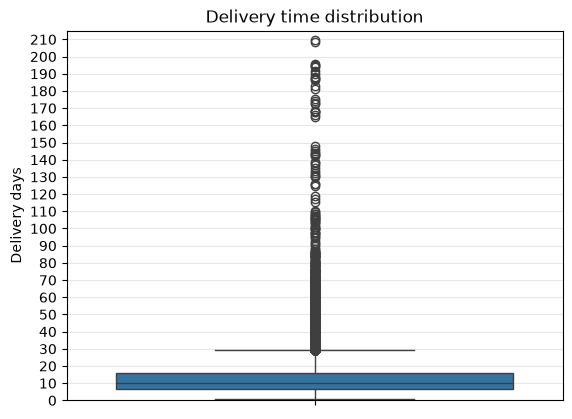

In [9]:
sns.boxplot(delivered['delivery_days'])
plt.ylabel("Delivery days")
plt.title("Delivery time distribution")
plt.ylim(0, 215)
plt.yticks(range(0, 215, 10))
plt.show()

In [10]:
for threshold in [30, 45, 60, 100]:
    mask = delivered['delivery_days'] >= threshold
    print(f"Orders with >= {threshold} days: {mask.sum()}, ({mask.mean()*100:.2f}%)")


Orders with >= 30 days: 4550, (4.72%)
Orders with >= 45 days: 1092, (1.13%)
Orders with >= 60 days: 306, (0.32%)
Orders with >= 100 days: 64, (0.07%)


In [11]:
delivered['delivery_days'].quantile([0.5, 0.9, 0.95, 0.99, 0.999, 1.0])

0.500     10.217477
0.900     23.096377
0.950     29.274046
0.990     46.050262
0.999     83.141065
1.000    209.628611
Name: delivery_days, dtype: float64

In [12]:
clean = delivered.copy()
print("Rows kept:", len(clean))
print(clean['delivery_days'].describe().round(2))

Rows kept: 96470
count    96470.00
mean        12.56
std          9.55
min          0.53
25%          6.77
50%         10.22
75%         15.72
max        209.63
Name: delivery_days, dtype: float64


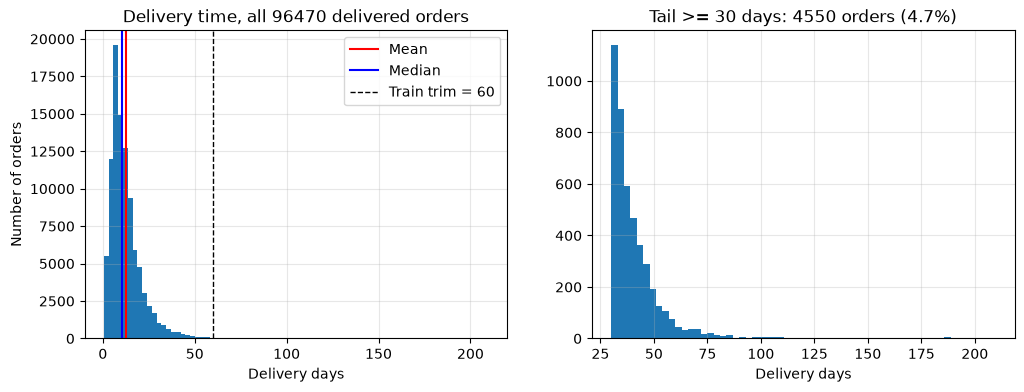

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(clean['delivery_days'], bins=80)
axes[0].axvline(clean['delivery_days'].mean(), color='red', label='Mean')
axes[0].axvline(clean['delivery_days'].median(), color='blue', label='Median')
axes[0].axvline(60, color='black', linestyle='--', linewidth=1, label='Train trim = 60')
axes[0].legend()
axes[0].set_title(f"Delivery time, all {len(clean)} delivered orders")
axes[0].set_xlabel("Delivery days")
axes[0].set_ylabel("Number of orders")

tail = clean[clean['delivery_days'] >= 30]
axes[1].hist(tail['delivery_days'], bins=60)
axes[1].set_title(f"Tail >= 30 days: {len(tail)} orders ({len(tail)/len(clean)*100:.1f}%)")
axes[1].set_xlabel("Delivery days")

plt.show()

The tail stays in the data. The 60-day threshold applies at training time, on train only.
delivery_days is unknown at prediction time, so these orders cannot be filtered out of test.
Test is evaluated as is.

In [14]:
clean['purchase_month'] = clean['order_purchase_timestamp'].dt.month
clean['purchase_day_of_week'] = clean['order_purchase_timestamp'].dt.dayofweek

In [15]:
clean.groupby('purchase_month')['delivery_days'].mean()

purchase_month
1     13.943059
2     16.184630
3     15.408157
4     12.364333
5     11.385740
6     10.180754
7      9.975710
8      9.090552
9     11.861356
10    12.289363
11    15.161132
12    15.392978
Name: delivery_days, dtype: float64

In [16]:
clean.groupby('purchase_day_of_week')['delivery_days'].mean()

purchase_day_of_week
0    11.998224
1    12.075733
2    12.442995
3    12.740592
4    13.573355
5    13.362731
6    11.957633
Name: delivery_days, dtype: float64

In [17]:
clean['purchase_year'] = clean['order_purchase_timestamp'].dt.year
clean.groupby('purchase_year')['delivery_days'].agg(['mean', 'count'])

,mean,count
purchase_year,,
2016,19.676608,267
2017,13.025527,43426
2018,12.137693,52777


## 3. Reference baseline: Olist's own estimate

In [18]:
clean['order_estimated_delivery_date'] = pd.to_datetime(clean['order_estimated_delivery_date'])

clean['estimated_days'] = (
    clean['order_estimated_delivery_date'] + pd.Timedelta(days=1) - clean['order_purchase_timestamp']
).dt.total_seconds() / 86400

clean[['estimated_days', 'delivery_days']].corr()

,estimated_days,delivery_days
estimated_days,1.000000,0.383599
delivery_days,0.383599,1.000000


In [19]:
clean['estimation_error'] = clean['estimated_days'] - clean['delivery_days']
clean['estimation_error'].describe()

count    96470.000000
mean        12.178126
std         10.184354
min       -187.975081
25%          7.389815
50%         12.948102
75%         17.244065
max        147.016123
Name: estimation_error, dtype: float64

<Axes: ylabel='estimation_error'>

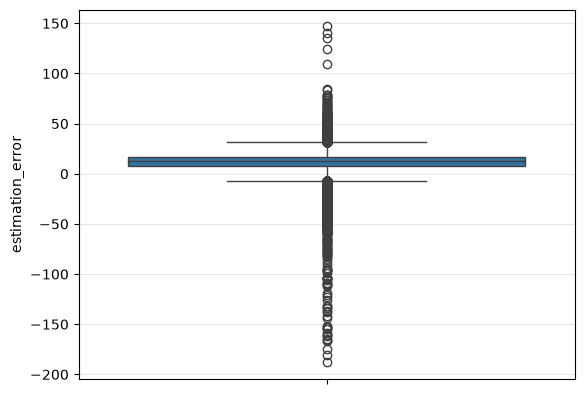

In [20]:
sns.boxplot(clean['estimation_error'])

In [21]:
print(f"Error over 100 days:", (clean['estimation_error'] >= 100).sum())

Error over 100 days: 5


In [22]:
late_strict = (clean['order_delivered_customer_date'] > clean['order_estimated_delivery_date']).mean()
late_eod = (clean['delivery_days'] > clean['estimated_days']).mean()

print(f"Late, raw timestamp comparison: {late_strict*100:.2f}%")
print(f"Late, end-of-day promise: {late_eod*100:.2f}%")

Late, raw timestamp comparison: 8.11%
Late, end-of-day promise: 6.77%


Olist's estimated date has time 00:00:00. Compared literally, a parcel arriving at 2pm on the
promised day counts as late, 8.11%. Read as "by end of day D", the way a customer reads it,
the rate is 6.77%. Everything below uses the second reading.

In [23]:
print("On-time (end of day):", round((1 - late_eod) * 100, 1), "%")
print("Average buffer:", round(clean['estimation_error'].mean(), 1), "days")
print("Median buffer:", round(clean['estimation_error'].median(), 1), "days")
print("Correlation estimate vs actual:", round(clean[['estimated_days','delivery_days']].corr().iloc[0,1], 2))

On-time (end of day): 93.2 %
Average buffer: 12.2 days
Median buffer: 12.9 days
Correlation estimate vs actual: 0.38


In [24]:
print("MAE Olist estimate:", clean['estimation_error'].abs().mean().round(2))
print("MAE naive baseline: ", (clean['delivery_days'] - clean['delivery_days'].mean()).abs().mean().round(2))

MAE Olist estimate: 13.57
MAE naive baseline:  6.41


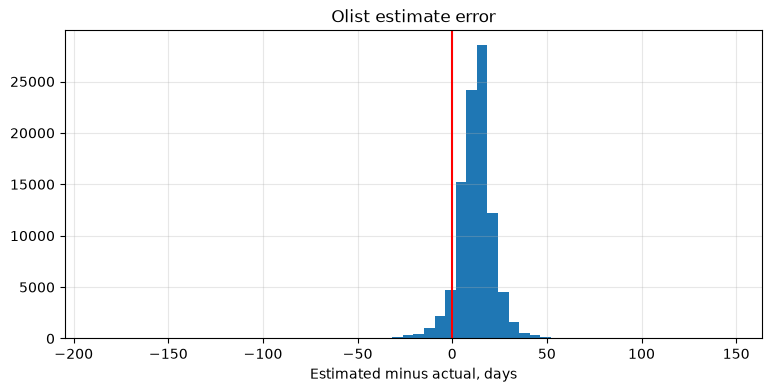

In [25]:
clean['estimation_error'].hist(bins=60, figsize=(9,4))
plt.axvline(0, color='red')
plt.xlabel('Estimated minus actual, days')
plt.title('Olist estimate error')
plt.savefig('../images/olist_estimate_error.png', dpi=150, bbox_inches='tight')
plt.show()

Olist is on time in 93% of orders, bought with a 12-day buffer. MAE 13.57,
correlation with actual 0.38 — calibrated for safety, not accuracy. Notebook 03
uses a per-state median as the bar to beat.

In [26]:
print("Rows: ", len(clean))
print("Unique order ID: ", clean['order_id'].nunique())

Rows:  96470
Unique order ID:  96470


## 4. Time features

In [27]:
clean['is_weekend'] = (clean['purchase_day_of_week'] >= 5).astype(int)

In [28]:
clean.groupby('is_weekend')['delivery_days'].mean()

is_weekend
0    12.537948
1    12.626079
Name: delivery_days, dtype: float64

In [29]:
clean = clean.drop(columns='is_weekend')

is_weekend: no effect (12.54 vs 12.63). Dropped.

In [30]:
clean['purchase_hour'] = clean['order_purchase_timestamp'].dt.hour
clean.groupby('purchase_hour')['delivery_days'].agg(['mean', 'count'])

,mean,count
purchase_hour,,
0,13.317256,2321
1,12.918100,1133
2,12.676438,496
3,12.448577,259
4,11.682573,203
5,12.043828,182
6,12.559076,477
7,12.046473,1199
8,12.083551,2907


In [31]:
clean = clean.drop(columns='purchase_hour')

purchase_hour: noise. "Fastest" hour 4am has 203 orders vs 6475 at 4pm. Daytime
hours all within 12.0-12.8. Also dropped.

Both checks in this section run on the full period. Both features are flat
everywhere, so the verdict does not depend on the window.

## 5. Geography: states & same_state

In [32]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

In [33]:
customers.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [34]:
customers['customer_city'].value_counts().head(20)

customer_city
sao paulo                15540
rio de janeiro            6882
belo horizonte            2773
brasilia                  2131
curitiba                  1521
campinas                  1444
porto alegre              1379
salvador                  1245
guarulhos                 1189
sao bernardo do campo      938
niteroi                    849
santo andre                797
osasco                     746
santos                     713
goiania                    692
sao jose dos campos        691
fortaleza                  654
sorocaba                   633
recife                     613
florianopolis              570
Name: count, dtype: int64

In [35]:
clean = clean.merge(customers[['customer_id', 'customer_state', 'customer_city']], on = 'customer_id', how='left')
print(clean.shape)

(96470, 16)


In [36]:
clean.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,purchase_day_of_week,purchase_year,estimated_days,estimation_error,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,10,0,2017,16.544062,8.107488,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,7,1,2018,20.137766,6.355729,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,8,2,2018,27.639711,18.245498,GO,vianopolis


In [37]:
clean['is_late'] = (clean['delivery_days'] > clean['estimated_days']).astype(int)

by_state = (clean.groupby('customer_state')
            .agg(orders=('order_id', 'count'),
                 avg_days=('delivery_days', 'mean'),
                 median_days=('delivery_days', 'median'),
                 late_rate=('is_late', 'mean'))
            .sort_values('avg_days'))

print(by_state.round(2).to_string())

                orders  avg_days  median_days  late_rate
customer_state                                          
SP               40494      8.76         7.21       0.04
PR                4923     11.99        10.43       0.04
MG               11354     12.01        10.31       0.05
DF                2080     12.97        11.36       0.06
SC                3546     14.95        13.01       0.08
RS                5344     15.30        13.18       0.06
RJ               12350     15.31        12.04       0.12
GO                1957     15.61        13.95       0.07
MS                 701     15.62        13.94       0.10
ES                1995     15.79        13.64       0.11
TO                 274     17.66        15.87       0.10
MT                 886     18.06        16.11       0.06
PE                1593     18.45        15.70       0.10
RN                 474     19.28        16.06       0.09
BA                3256     19.34        16.91       0.12
RO                 243     19.3

8.8 days in SP to 29.4 in RR, but RR has 41 orders and SP tens of thousands.
`customer_state` is a strong feature with very uneven support.

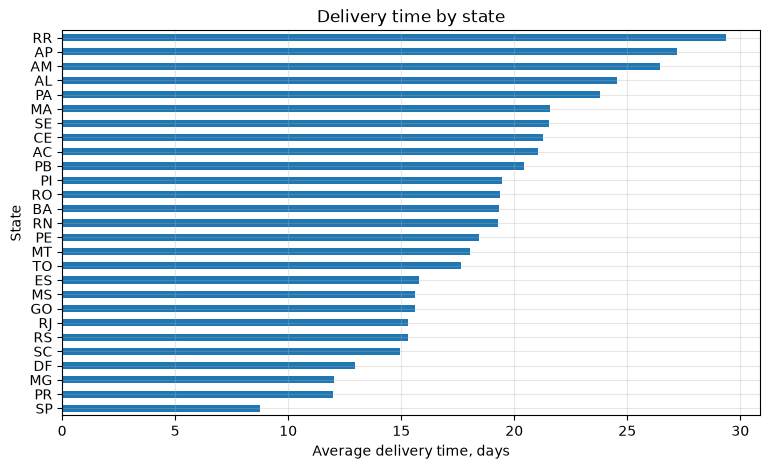

In [38]:
state_stats = (clean.groupby('customer_state')['delivery_days'].mean().sort_values())

state_stats.plot.barh(figsize=(9,5))
plt.xlabel("Average delivery time, days")
plt.ylabel("State")
plt.title("Delivery time by state")
plt.show()


## 6. Product features

In [39]:
items    = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")

print("items:", items.shape, "  products:", products.shape)
print("product_id unique:", products['product_id'].is_unique)
print("\nMissing in products:")
print(products.isnull().sum().to_string())

items: (112650, 7)   products: (32951, 9)
product_id unique: True

Missing in products:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2


In [40]:
products_cols = ['product_id', 'product_category_name', 'product_weight_g',
                 'product_length_cm', 'product_height_cm', 'product_width_cm']

items_prod = items.merge(products[products_cols], on='product_id', how='left')

items_prod['item_volume_cm3'] = (items_prod['product_length_cm'] *
                                 items_prod['product_height_cm'] *
                                 items_prod['product_width_cm'])

print(items_prod.shape)
items_prod.head(3)

(112650, 13)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_weight_g,product_length_cm,product_height_cm,product_width_cm,item_volume_cm3
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,650.0,28.0,9.0,14.0,3528.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93,pet_shop,30000.0,50.0,30.0,40.0,60000.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,moveis_decoracao,3050.0,33.0,13.0,33.0,14157.0


In [41]:
items_agg = items_prod.groupby('order_id').agg(
    total_price      = ('price', 'sum'),
    total_freight    = ('freight_value', 'sum'),
    quantity_items   = ('order_item_id', 'count'),
    n_sellers        = ('seller_id', 'nunique'),
    total_weight_g   = ('product_weight_g', 'sum'),
    total_volume_cm3 = ('item_volume_cm3', 'sum'),
    max_length_cm    = ('product_length_cm', 'max'),
    max_height_cm    = ('product_height_cm', 'max'),
    max_width_cm     = ('product_width_cm', 'max'),
).reset_index()

for c in ['total_weight_g', 'total_volume_cm3']:
    items_agg.loc[items_agg[c] == 0, c] = np.nan

print(items_agg.shape)
print("NaN weight:", items_agg['total_weight_g'].isnull().sum())

(98666, 10)
NaN weight: 22


22 orders lose weight, 16 lose dimensions. sum() turns all-NaN groups into 0, so those are set
back to NaN.

In [42]:
main_item = (items_prod
             .sort_values(['order_id', 'price'], ascending=[True, False])
             .drop_duplicates('order_id')
             [['order_id', 'seller_id', 'product_category_name']])

print(main_item.shape)

(98666, 3)


In [43]:
clean = clean.merge(items_agg, on='order_id', how='left')
clean = clean.merge(main_item, on='order_id', how='left')
print(clean.shape)

(96470, 28)


In [44]:
clean.info()
clean.head(3)

<class 'pandas.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  str           
 1   customer_id                    96470 non-null  str           
 2   order_status                   96470 non-null  str           
 3   order_purchase_timestamp       96470 non-null  datetime64[us]
 4   order_approved_at              96456 non-null  str           
 5   order_delivered_carrier_date   96469 non-null  str           
 6   order_delivered_customer_date  96470 non-null  datetime64[us]
 7   order_estimated_delivery_date  96470 non-null  datetime64[us]
 8   delivery_days                  96470 non-null  float64       
 9   purchase_month                 96470 non-null  int32         
 10  purchase_day_of_week           96470 non-null  int32         
 11  purchase_year             

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,purchase_month,...,total_freight,quantity_items,n_sellers,total_weight_g,total_volume_cm3,max_length_cm,max_height_cm,max_width_cm,seller_id,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.436574,10,...,8.72,1,1,500.0,1976.0,19.0,8.0,13.0,3504c0cb71d7fa48d967e0e4c94d59d9,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.782037,7,...,22.76,1,1,400.0,4693.0,19.0,13.0,19.0,289cdb325fb7e7f891c38608bf9e0962,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.394213,8,...,19.22,1,1,420.0,9576.0,24.0,19.0,21.0,4869f7a5dfa277a7dca6462dcf3b52b2,automotivo


In [45]:
clean['n_sellers'].value_counts()

n_sellers
1    95195
2     1216
3       54
4        3
5        2
Name: count, dtype: int64

Product features are summed over all items in the order. Weight, volume, price, freight.
Dimensions taken as max. Category and seller come from the most expensive item. 98% of orders
have one item anyway.

In [46]:
sellers = pd.read_csv('../data/raw/olist_sellers_dataset.csv')
clean = clean.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
print(clean.shape)

(96470, 29)


In [47]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  str           
 1   customer_id                    96470 non-null  str           
 2   order_status                   96470 non-null  str           
 3   order_purchase_timestamp       96470 non-null  datetime64[us]
 4   order_approved_at              96456 non-null  str           
 5   order_delivered_carrier_date   96469 non-null  str           
 6   order_delivered_customer_date  96470 non-null  datetime64[us]
 7   order_estimated_delivery_date  96470 non-null  datetime64[us]
 8   delivery_days                  96470 non-null  float64       
 9   purchase_month                 96470 non-null  int32         
 10  purchase_day_of_week           96470 non-null  int32         
 11  purchase_year             

In [48]:
clean['same_state'] = (clean['customer_state'] == clean['seller_state']).astype(int)
clean.groupby('same_state')['delivery_days'].agg(['mean', 'count']).round(2)

,mean,count
same_state,,
0,15.15,61780
1,7.94,34690


In [49]:
sp = clean[clean['customer_state'] == 'SP']
sp.groupby('same_state')['delivery_days'].agg(['mean', 'count']).round(2)

,mean,count
same_state,,
0,11.33,9772
1,7.95,30722


same_state: 15.15 vs 7.94 overall. But almost all same_state=1 orders are from SP,
which is the fastest state anyway. Within SP the gap drops to 3.38 days. Kept.

In [50]:
print(clean.shape)

(96470, 30)


In [51]:
clean['product_category_name'] = clean['product_category_name'].fillna('unknown')

In [52]:
clean.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
delivery_days                     0
purchase_month                    0
purchase_day_of_week              0
purchase_year                     0
estimated_days                    0
estimation_error                  0
customer_state                    0
customer_city                     0
is_late                           0
total_price                       0
total_freight                     0
quantity_items                    0
n_sellers                         0
total_weight_g                   22
total_volume_cm3                 16
max_length_cm                    16
max_height_cm                    16
max_width_cm                     16
seller_id                         0
product_category_name       

These are not features: order_approved_at, order_delivered_carrier_date, estimated_days,
estimation_error.

In [53]:
clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 96470 entries, 0 to 96469
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96470 non-null  str           
 1   customer_id                    96470 non-null  str           
 2   order_status                   96470 non-null  str           
 3   order_purchase_timestamp       96470 non-null  datetime64[us]
 4   order_approved_at              96456 non-null  str           
 5   order_delivered_carrier_date   96469 non-null  str           
 6   order_delivered_customer_date  96470 non-null  datetime64[us]
 7   order_estimated_delivery_date  96470 non-null  datetime64[us]
 8   delivery_days                  96470 non-null  float64       
 9   purchase_month                 96470 non-null  int32         
 10  purchase_day_of_week           96470 non-null  int32         
 11  purchase_year             

## 7. Feature summary and target drift

In [54]:
num_cols = ['delivery_days', 'total_price', 'total_freight', 'quantity_items',
            'total_volume_cm3', 'total_weight_g', 'same_state']
clean[num_cols].corr()['delivery_days'].sort_values(ascending=False).round(3)

delivery_days       1.000
total_freight       0.167
total_weight_g      0.071
total_volume_cm3    0.063
total_price         0.056
quantity_items     -0.019
same_state         -0.362
Name: delivery_days, dtype: float64

Numeric features are weak on their own. total_freight is best at 0.17, and it partly
just measures distance. same_state at -0.36 looks like signal but section 5 shows it
is mostly SP.

In [55]:
print(clean['customer_state'].nunique())
print(clean['seller_state'].nunique())
print(clean['product_category_name'].nunique())

27
22
74


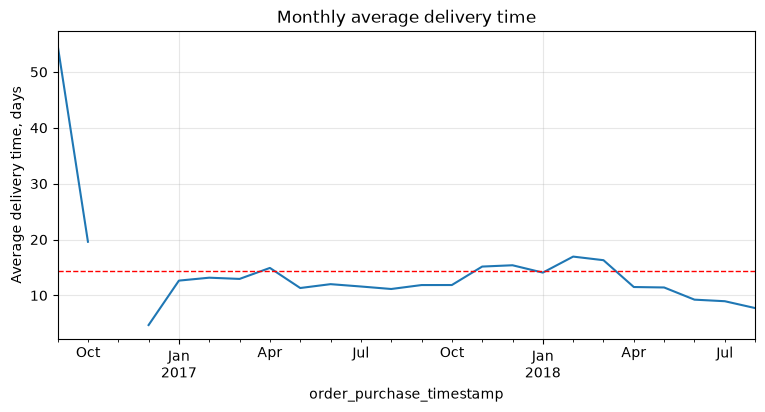

In [56]:
monthly = (clean.set_index('order_purchase_timestamp').resample('ME')['delivery_days'].mean())

monthly.plot(figsize=(9,4))
plt.axhline(monthly.mean(), color = 'red', linestyle = '--', linewidth=1)
plt.ylabel("Average delivery time, days")
plt.title("Monthly average delivery time")
plt.show()

2016 has 267 orders, monthly averages there are noise.
2017 to early 2018 sits at 11 to 17 days. From July 2018 it drops to 8 to 10.

Delivery time drifts across the period. The split has to be time-based, and baseline MAE
recalculated on the test set.

## 8. Distance feature

In [57]:
geo = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
print(geo.shape)
print(geo['geolocation_zip_code_prefix'].nunique())

(1000163, 5)
19015


In [58]:
geo.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [59]:
BR_LAT = (-34.0, 6.0)
BR_LNG = (-74.0, -34.0)

before = len(geo)
geo = geo[geo['geolocation_lat'].between(*BR_LAT) &
          geo['geolocation_lng'].between(*BR_LNG)]
print(f"Geo rows dropped as out of Brazil: {before - len(geo)}")

geo_agg = (geo.groupby('geolocation_zip_code_prefix')
           .agg(lat=('geolocation_lat', 'median'),
                lng=('geolocation_lng', 'median')))

print(geo_agg.shape)

Geo rows dropped as out of Brazil: 42
(19010, 2)


Geolocation: 42 rows point outside Brazil, mostly Portugal. Dropped by bounding box
before aggregation. Max distance falls to 3399 km.

In [60]:
def haversine_km (lat1, lng1, lat2, lng2):
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlng / 2)**2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

In [61]:
clean = clean.merge(customers[['customer_id', 'customer_zip_code_prefix']], on='customer_id', how='left')

In [62]:
clean = clean.merge(
    geo_agg,
    left_on='customer_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).rename(columns={'lat':  'customer_lat', 'lng': 'customer_lng'})

print(clean.shape)

(96470, 33)


In [63]:
clean = clean.merge(sellers[['seller_id', 'seller_zip_code_prefix']], on='seller_id', how='left')

clean = clean.merge(
    geo_agg,
    left_on='seller_zip_code_prefix',
    right_on='geolocation_zip_code_prefix',
    how='left'
).rename(columns={'lat': 'seller_lat', 'lng': 'seller_lng'})

print(clean.shape)

(96470, 36)


In [64]:
print(clean[['customer_lat', 'customer_lng']].isnull().sum())
print(clean[['seller_lat', 'seller_lng']].isnull().sum())

customer_lat    265
customer_lng    265
dtype: int64
seller_lat    213
seller_lng    213
dtype: int64


In [65]:
clean['distance_km'] = haversine_km(
    clean['customer_lat'], clean['customer_lng'],
    clean['seller_lat'], clean['seller_lng']
)

print(clean['distance_km'].describe())
print("NaN distance: ", clean['distance_km'].isnull().sum())

count    95993.000000
mean       600.395276
std        592.359858
min          0.000000
25%        185.222783
50%        433.798491
75%        798.282822
max       3398.485605
Name: distance_km, dtype: float64
NaN distance:  477


In [66]:
print("Max distance:", round(clean['distance_km'].max(), 1))
assert clean['distance_km'].max() < 4500, "Geo outliers survived the bounding box filter"
print("NaN distance:", clean['distance_km'].isnull().sum())
print("Zero distance:", (clean['distance_km'] == 0).sum())

Max distance: 3398.5
NaN distance: 477
Zero distance: 23


In [67]:
clean.to_parquet('../data/clean/clean.parquet', engine='fastparquet')
geo_agg.to_parquet('../models/zip_coords.parquet')

distance_km: haversine between customer and seller zip centroids. Geolocation rows
outside Brazil's bounding box are dropped before aggregation, so no post-hoc outlier
cleanup is needed. 477 orders get NaN from missing coordinates. Imputation happens
in the modeling notebook, on train only.

## Summary: implications for modelling

1. Geography dominates: **8.8 days** in São Paulo to **23.8** in Pará among
   states with real volume. `customer_state` is the strongest feature, with
   very uneven support.

2. Delivery time drifts — **11 to 17 days** through early 2018, then **8 to 10**.
   The split has to be time-based, baselines recomputed on test.

3. Numeric features are weak alone. Freight is best at **0.17**, and it mostly
   proxies distance.

4. Time of purchase is flat. Weekday, weekend and hour tested and dropped.

5. Olist's estimate: 93% on time on a **12-day** buffer, MAE **13.57** —
   calibrated for safety, so a poor benchmark.

Notebook 03 predicts delivery time at checkout. Naive mean gives MAE **6.41**;
a per-state median is the bar to beat.